In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
from collections import defaultdict
import os
import pprint

import hydra
from omegaconf import OmegaConf
from einops import rearrange
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.3, palette=sns.color_palette('husl'),)
import sqlalchemy as sa

from conf import conf
from dafm import datasets, models, utils

In [4]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [9]:
engine = conf.get_engine()
with conf.sa.orm.Session(engine) as db:
    cfg = db.execute(sa.select(conf.Conf).where(conf.Conf.alt_id == 'v8og9szz')).first()[0]
    pprint.pp(cfg)

Conf(root_dir='/root/workspace/GitHub/Data-Assimilation-Flow-Matching',
     out_dir='/root/workspace/out/dafm',
     run_subdir='runs',
     prediction_filename='trajectories.parquet',
     device='cuda',
     alt_id='v8og9szz',
     rng_seed=2376999025,
     fit=True,
     id=3,
     dataset=DoubleWell(predicted_state_count=1000,
                        time_step_count=100,
                        time_step_size=0.1,
                        sa_inheritance='DoubleWell',
                        id=1,
                        model_std=0.2,
                        observation_std=0.1,
                        true_state_initial_condition_std=0.02,
                        predicted_state_initial_condition_std=0.2),
     model=ScoreMatching(sa_inheritance='ScoreMatching',
                         id=2,
                         epoch_count=600,
                         batch_size=1000,
                         shuffle_training_samples=True,
                         embedding_dimension=50,
  

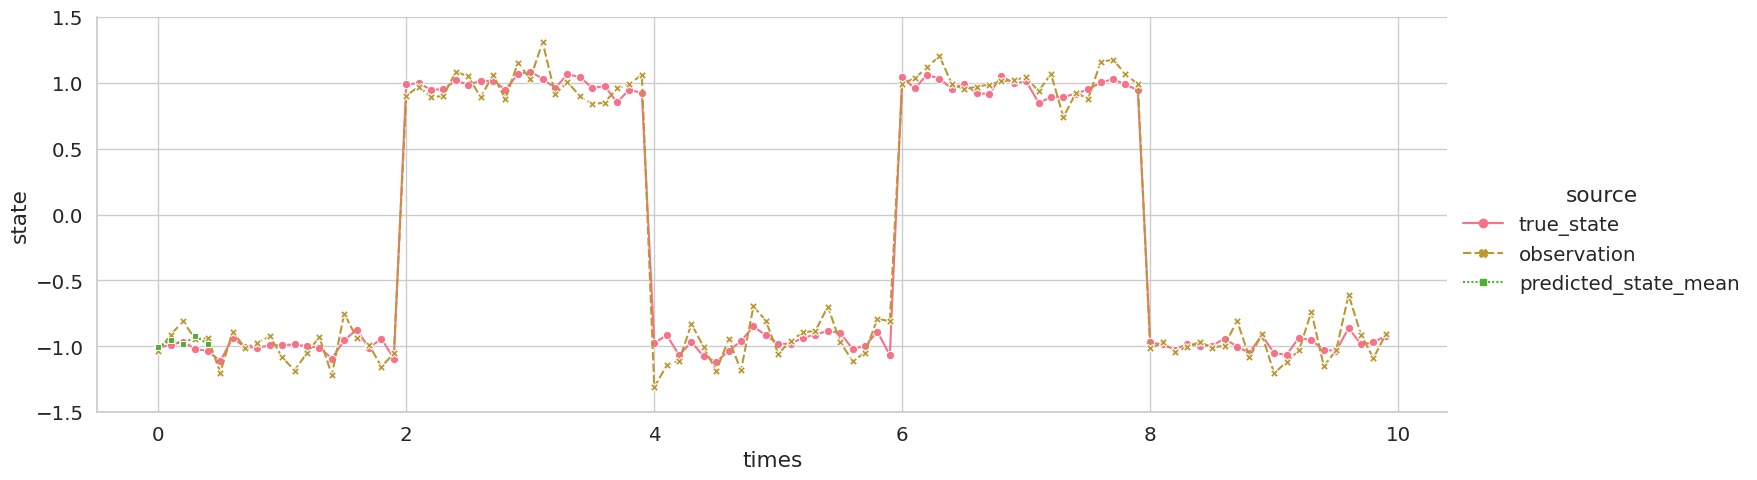

In [17]:
df = (
    pd.read_parquet(cfg.run_dir/cfg.prediction_filename)
    .melt(id_vars='times', var_name='source', value_name='state')
)
(
    sns.relplot(
        data=df,
        kind='line',
        x='times',
        y='state',
        hue='source',
        style='source',
        markers=True,
        aspect=3,
        # hue_order=['true_state', 'predicted_state_mean'],
    )
    .set(ylim=(-1.5, 1.5))
)